In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\master_dataset.csv"
df = pd.read_csv(data_path)

df['datetime'] = pd.to_datetime(df['datetime'])


print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

print("\nFirst 3 rows:")
print(df.head(3))

Dataset loaded successfully!
Shape: (40984, 14)

First 3 rows:
             datetime    city  temp  humidity   dew  windspeed  windgust  \
0 2021-11-01 00:00:00  Lahore  19.0     63.73  12.0        0.4      13.7   
1 2021-11-01 01:00:00  Lahore  19.0     63.93  12.0        0.3      12.6   
2 2021-11-01 02:00:00  Lahore  18.5     67.31  12.3        0.3      12.6   

   winddir  sealevelpressure  cloudcover  visibility  precip  snow  snowdepth  
0    106.0            1012.0         0.0         4.0     0.0     0        0.0  
1    106.0            1012.0         0.0         4.0     0.0     0        0.0  
2     11.0            1012.2         0.0         4.0     0.0     0        0.0  


In [6]:
print("Basic statistics:")
print(df.describe().round(2))

Basic statistics:
                            datetime      temp  humidity       dew  windspeed  \
count                          40984  40984.00  40984.00  40984.00   40984.00   
mean   2023-08-11 22:11:28.922506240     14.55     68.13      7.98       3.64   
min              2021-11-01 00:00:00     -1.20      5.83    -22.00       0.00   
25%              2022-11-11 12:45:00     10.00     52.83      5.30       0.00   
50%              2023-11-28 12:30:00     14.00     71.90      8.30       1.40   
75%              2024-11-14 06:00:00     19.00     83.81     11.00       6.50   
max              2025-02-28 23:00:00     34.50    100.00     28.30      63.10   
std                              NaN      5.97     19.45      5.14       4.73   

       windgust   winddir  sealevelpressure  cloudcover  visibility    precip  \
count   40984.0  40984.00          40984.00    40984.00    40984.00  40984.00   
mean       13.5    159.40           1016.68       24.74        7.64      0.04   
min      

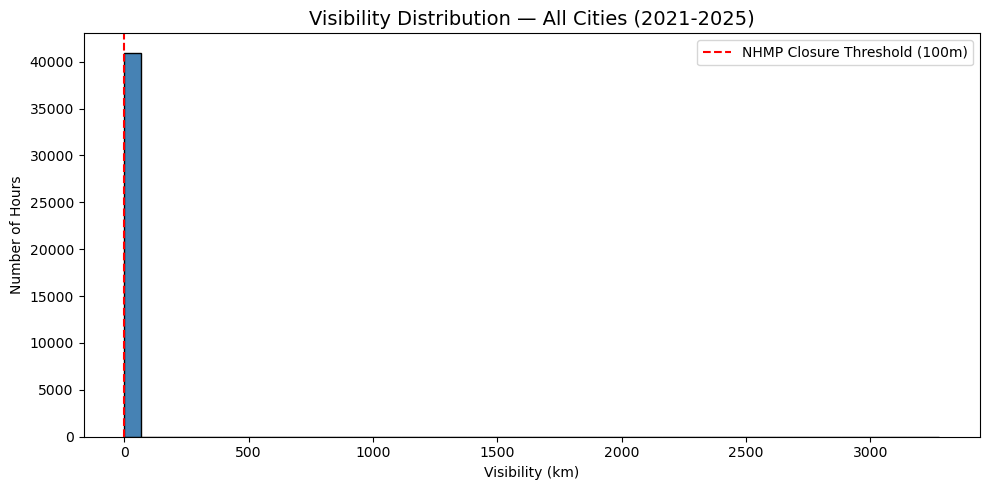

Graph saved!


In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df['visibility'], bins=50, color='steelblue', edgecolor='black')
plt.title('Visibility Distribution — All Cities (2021-2025)', fontsize=14)
plt.xlabel('Visibility (km)')
plt.ylabel('Number of Hours')
plt.axvline(x=0.1, color='red', linestyle='--', label='NHMP Closure Threshold (100m)')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\visibility_distribution.png", dpi=150)
plt.show()
print("Graph saved!")

Before outlier removal: 40984
After outlier removal: 40976


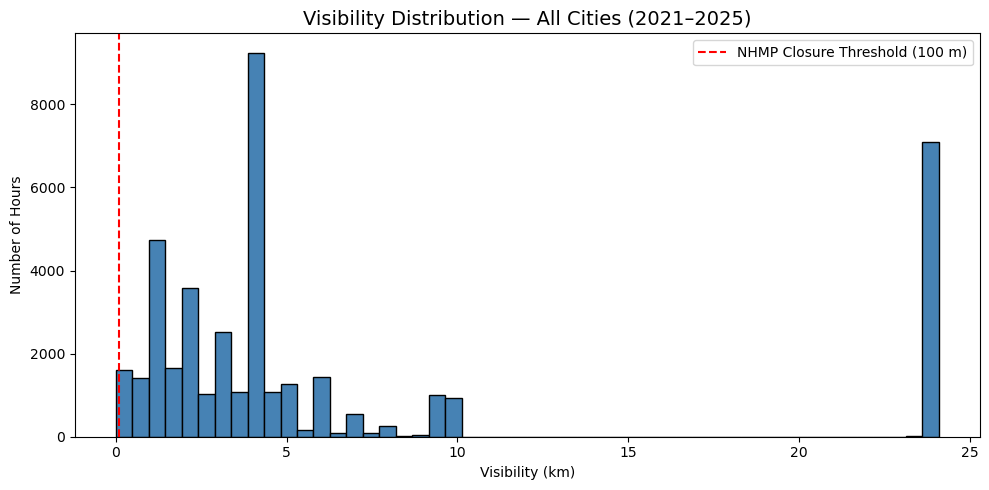

Done!


In [10]:
# Remove outliers — visibility physically max ~48 km in Pakistan
print("Before outlier removal:", len(df))

df = df[df['visibility'] <= 48]

print("After outlier removal:", len(df))

# Redraw visibility distribution graph
plt.figure(figsize=(10, 5))

plt.hist(
    df['visibility'],
    bins=50,
    color='steelblue',
    edgecolor='black'
)

plt.title('Visibility Distribution — All Cities (2021–2025)', fontsize=14)
plt.xlabel('Visibility (km)')
plt.ylabel('Number of Hours')

# NHMP road closure threshold (100 m = 0.1 km)
plt.axvline(
    x=0.1,
    color='red',
    linestyle='--',
    label='NHMP Closure Threshold (100 m)'
)

plt.legend()
plt.tight_layout()

# Save the figure
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\visibility_distribution.png",
    dpi=150
)

plt.show()

print("Done!")

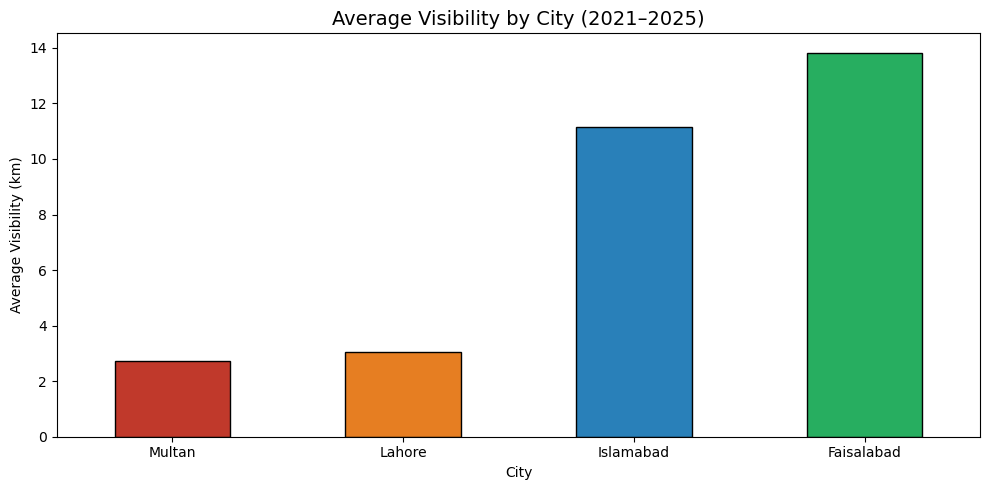

Done!


In [12]:
plt.figure(figsize=(10, 5))

df.groupby('city')['visibility'].mean().sort_values().plot(
    kind='bar',
    color=['#c0392b', '#e67e22', '#2980b9', '#27ae60'],
    edgecolor='black'
)

plt.title('Average Visibility by City (2021–2025)', fontsize=14)
plt.xlabel('City')
plt.ylabel('Average Visibility (km)')
plt.xticks(rotation=0)

plt.tight_layout()

# Save the figure
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\visibility_by_city.png",
    dpi=150
)

plt.show()

print("Done!")

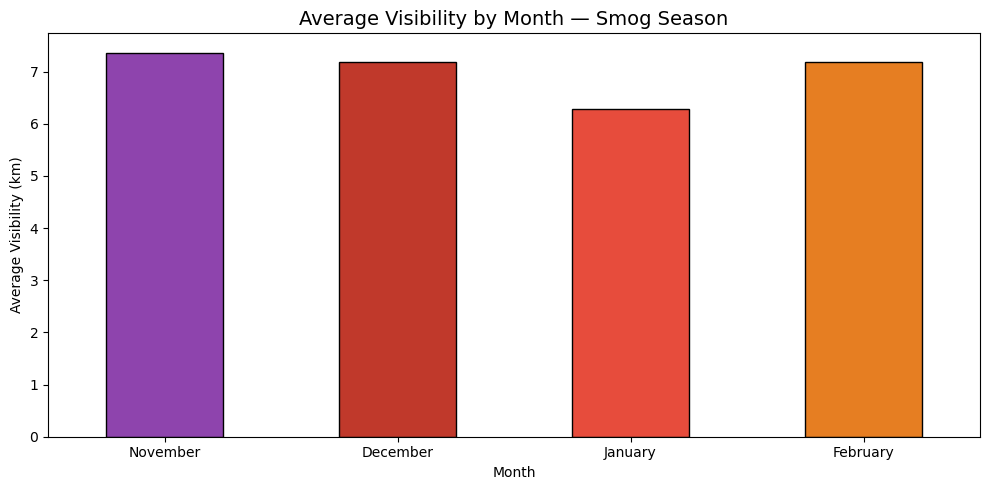

Done!


In [14]:
# Extract month from datetime
df['month'] = df['datetime'].dt.month

# Month names (for reference)
month_names = {
    11: 'November',
    12: 'December',
    1: 'January',
    2: 'February'
}

# Plot average visibility by month
plt.figure(figsize=(10, 5))

df.groupby('month')['visibility'].mean().reindex([11, 12, 1, 2]).plot(
    kind='bar',
    color=['#8e44ad', '#c0392b', '#e74c3c', '#e67e22'],
    edgecolor='black'
)

plt.title('Average Visibility by Month — Smog Season', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Visibility (km)')

plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=['November', 'December', 'January', 'February'],
    rotation=0
)

plt.tight_layout()

# Save the figure
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\visibility_by_month.png",
    dpi=150
)

plt.show()

print("Done!")

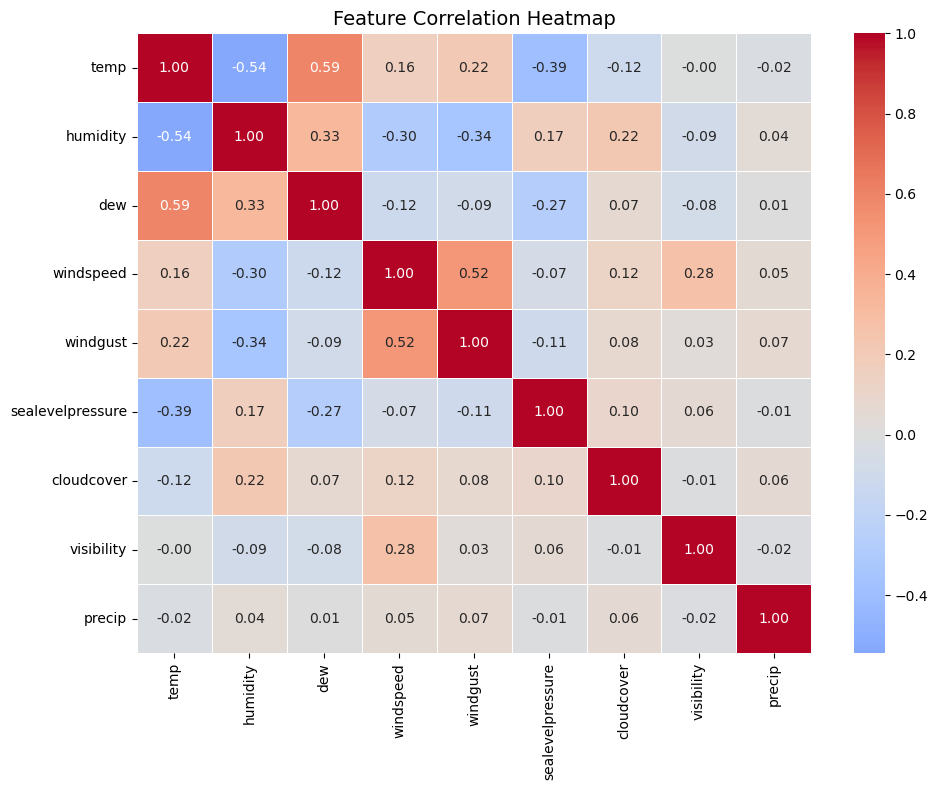

Done!


In [16]:
# Correlation Heatmap

plt.figure(figsize=(10, 8))

numeric_cols = [
    'temp',
    'humidity',
    'dew',
    'windspeed',
    'windgust',
    'sealevelpressure',
    'cloudcover',
    'visibility',
    'precip'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()

# Save the figure
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\correlation_heatmap.png",
    dpi=150
)

plt.show()

print("Done!")

In [18]:
output_path = r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\master_dataset.csv"
df.to_csv(output_path, index=False)
print(f"Final dataset saved: {df.shape}")

Final dataset saved: (40976, 15)
